# H1 — REC > 0

Simple one-sample t-tests by condition.

Hypothesis: Recognition Memory Index (REC) is above 0.

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats import ttest_1samp, shapiro, spearmanr, probplot, wilcoxon

sns.set(style='whitegrid', context='talk')

data_path = Path('..') / '01_Preprocessing' / 'compiled_preprocessed.csv'
df = pd.read_csv(data_path)
df['boundary_position'] = pd.Categorical(df['boundary_position'], categories=['Pre', 'Mid', 'Post'], ordered=True)

In [3]:
def p_resp(data, trial_type, response, boundary=None):
    x = data[data['trial_type'] == trial_type]
    if boundary is not None:
        x = x[x['boundary_position'] == boundary]
    if x.empty:
        return np.nan
    return (x['user_response'] == response).mean()

rows = []
for (pid, cond), sub in df.groupby(['participant_id', 'condition']):
    foil_old = p_resp(sub, 'Foil', 'Target')
    rec_vals = []
    for pos in ['Pre', 'Mid', 'Post']:
        hit = p_resp(sub, 'Target', 'Target', pos)
        rec_vals.append(hit - foil_old)
    rows.append({'participant_id': pid, 'condition': cond, 'REC': np.nanmean(rec_vals)})

rec_df = pd.DataFrame(rows)

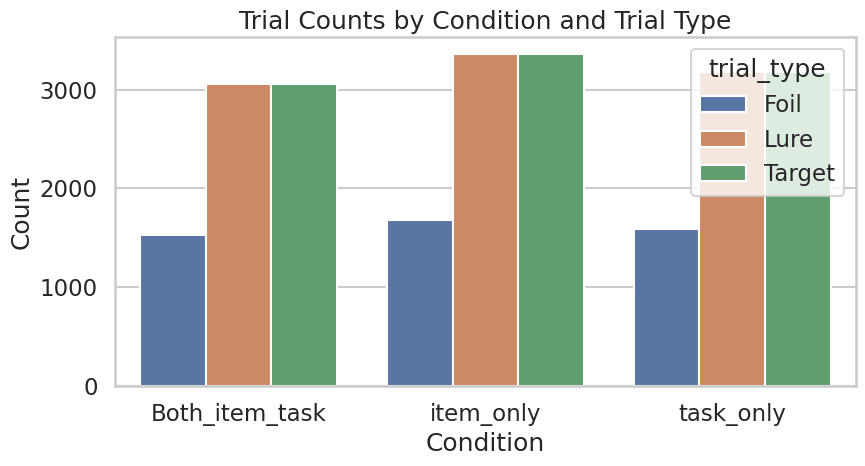

In [4]:
# Quick data visualization: trial counts by condition
trial_counts = df.groupby(['condition', 'trial_type']).size().reset_index(name='n')
plt.figure(figsize=(9, 5))
sns.barplot(data=trial_counts, x='condition', y='n', hue='trial_type')
plt.title('Trial Counts by Condition and Trial Type')
plt.xlabel('Condition')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Normality Check (prerequisite for t-test)

Before running one-sample t-tests we verify the normality assumption per condition using:
- **Q-Q plots** — visual check; points should fall on the diagonal
- **Shapiro-Wilk test** — formal test (p > .05 → cannot reject normality)
- **Spearman r on Q-Q points** — rank correlation between theoretical and sample quantiles; r close to 1 indicates a good normal fit

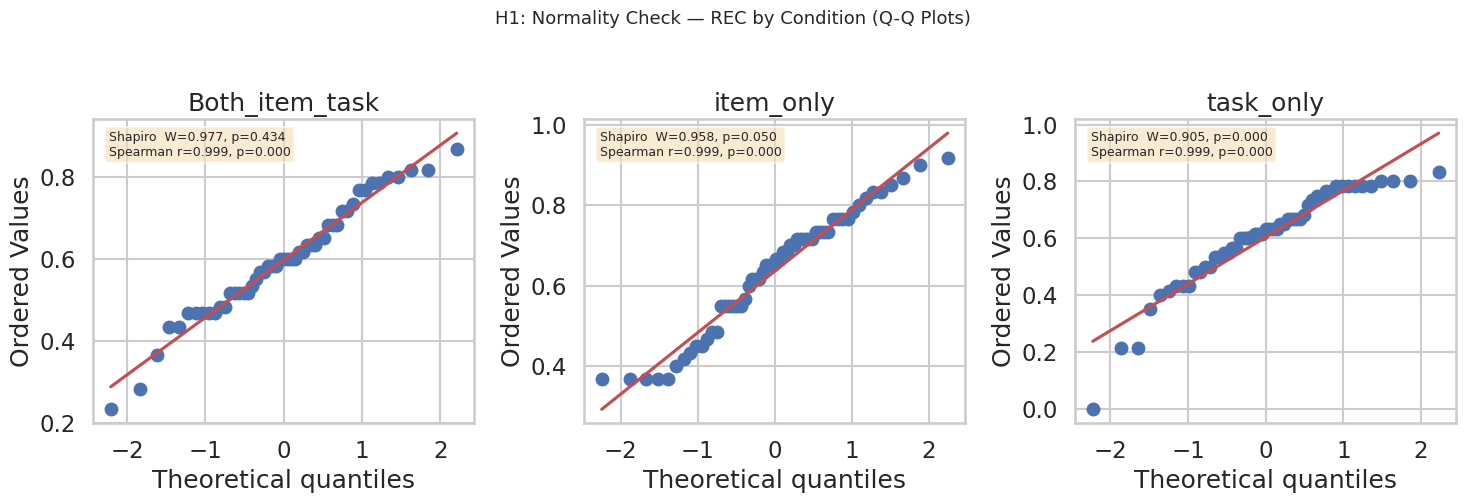

,condition,n,shapiro_W,shapiro_p,normal (p>.05),QQ_spearman_r,QQ_spearman_p
0,Both_item_task,51,0.9774,0.4340,True,0.9992,0.0
1,item_only,56,0.9582,0.0500,True,0.9989,0.0
2,task_only,53,0.9053,0.0005,False,0.9988,0.0


In [5]:
conditions = sorted(rec_df['condition'].unique())
fig, axes = plt.subplots(1, len(conditions), figsize=(5 * len(conditions), 5))
if len(conditions) == 1:
    axes = [axes]

normality_results = []
for ax, cond in zip(axes, conditions):
    vals = rec_df[rec_df['condition'] == cond]['REC'].dropna()

    # Q-Q plot against normal distribution
    (osm, osr), _ = probplot(vals, dist='norm', plot=ax)
    ax.set_title(f'{cond}')

    # Shapiro-Wilk normality test
    sw_stat, sw_p = shapiro(vals)

    # Spearman rank correlation between theoretical and sample quantiles
    spear_r, spear_p = spearmanr(osm, osr)

    normality_results.append({
        'condition': cond,
        'n': len(vals),
        'shapiro_W': round(sw_stat, 4),
        'shapiro_p': round(sw_p, 4),
        'normal (p>.05)': sw_p > 0.05,
        'QQ_spearman_r': round(spear_r, 4),
        'QQ_spearman_p': round(spear_p, 4),
    })

    ax.annotate(
        f'Shapiro  W={sw_stat:.3f}, p={sw_p:.3f}\nSpearman r={spear_r:.3f}, p={spear_p:.3f}',
        xy=(0.04, 0.88), xycoords='axes fraction', fontsize=9,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='wheat', alpha=0.6)
    )

plt.suptitle('H1: Normality Check — REC by Condition (Q-Q Plots)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

norm_df = pd.DataFrame(normality_results)
display(norm_df)

The task_only condition is found not to be normal. 
The non paramtric test is the "Wlcoxon signed rank test"

In [8]:
# task_only failed normality → Wilcoxon signed-rank test (one-sample, H0: median = 0)
# remaining conditions are normal → one-sample t-test

NON_PARAMETRIC = {'task_only'}

result = []
for cond, sub in rec_df.groupby('condition'):
    vals = sub['REC'].dropna()

    if cond in NON_PARAMETRIC:
        stat, p = wilcoxon(vals, alternative='greater')
        test_used = 'Wilcoxon signed-rank'
        stat_label = 'W'
    else:
        res = ttest_1samp(vals, popmean=0.0, alternative='greater')
        stat, p = res.statistic, res.pvalue
        test_used = 'one-sample t-test'
        stat_label = 't'

    result.append({
        'condition': cond,
        'test': test_used,
        'n': len(vals),
        'mean_REC': vals.mean(),
        f'stat ({stat_label})': round(stat, 4),
        'p_value': round(p, 6),
        'supported (p<.05)': p < 0.05
    })

result_df = pd.DataFrame(result).sort_values('condition')
display(result_df)

,condition,test,n,mean_REC,stat (t),p_value,supported (p<.05),stat (W)
0,Both_item_task,one-sample t-test,51,0.597059,30.9722,0.0,True,NaN
1,item_only,one-sample t-test,56,0.635701,31.3769,0.0,True,NaN
2,task_only,Wilcoxon signed-rank,53,0.604227,NaN,0.0,True,1378.0


### Visualzation

/tmp/ipykernel_560320/1934472486.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=rec_df, x='condition', y='REC', order=cond_order,
/tmp/ipykernel_560320/1934472486.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=rec_df, x='condition', y='REC', order=cond_order,


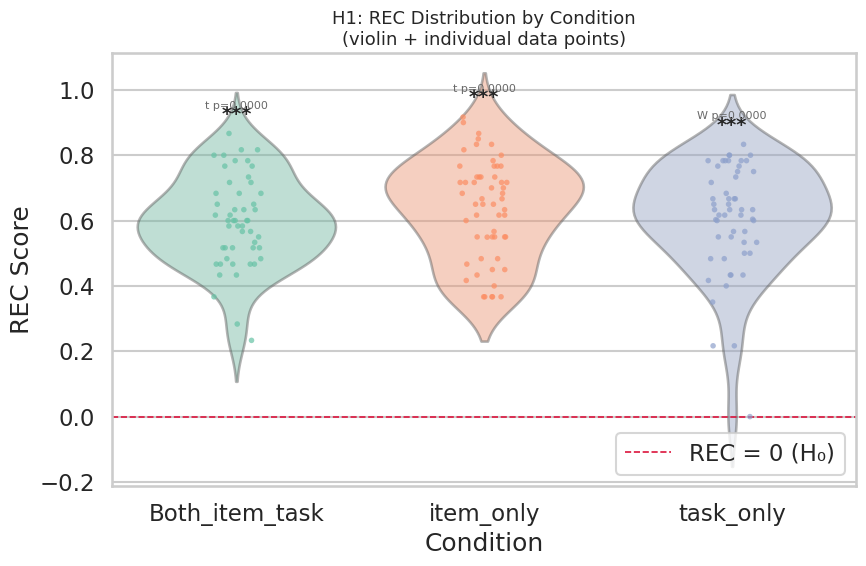

/tmp/ipykernel_560320/1934472486.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=rec_df, x='condition', y='REC', order=cond_order,


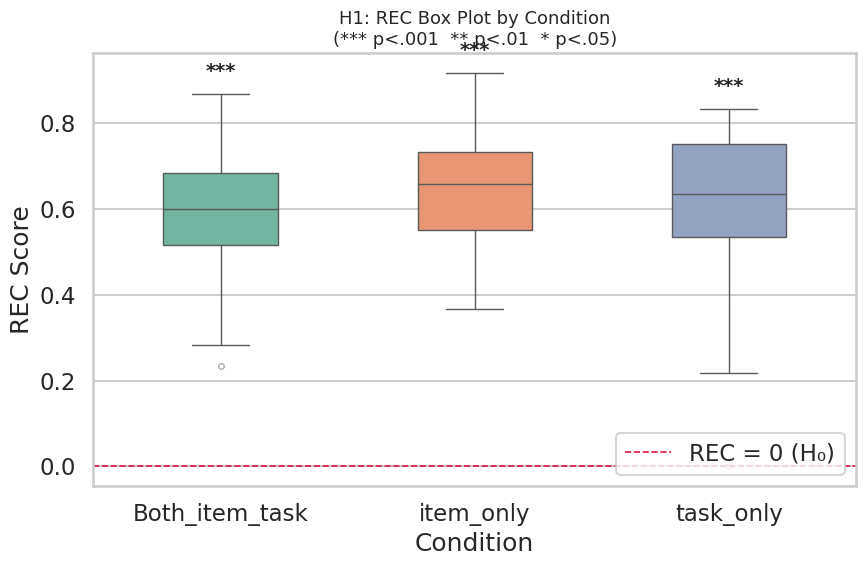

In [10]:
cond_order = sorted(rec_df['condition'].unique())
palette    = sns.color_palette('Set2', len(cond_order))

# --- helper: significance stars ---
def stars(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'ns'

stat_map = {row['condition']: row for _, row in result_df.iterrows()}

# ── Plot 1: Violin + strip (honest about non-normality) ──────────────────────
fig, ax = plt.subplots(figsize=(9, 6))
sns.violinplot(data=rec_df, x='condition', y='REC', order=cond_order,
               palette=palette, inner=None, alpha=0.45, ax=ax)
sns.stripplot(data=rec_df, x='condition', y='REC', order=cond_order,
              palette=palette, size=4, jitter=True, alpha=0.7, ax=ax)
ax.axhline(0, color='crimson', linestyle='--', linewidth=1.2, label='REC = 0 (H₀)')

# annotate significance above each violin
for i, cond in enumerate(cond_order):
    row  = stat_map[cond]
    p    = row['p_value']
    ymax = rec_df[rec_df['condition'] == cond]['REC'].max()
    ax.text(i, ymax + 0.03, stars(p), ha='center', va='bottom', fontsize=14, fontweight='bold')
    label = f"{'W' if row['test']=='Wilcoxon signed-rank' else 't'} p={p:.4f}"
    ax.text(i, ymax + 0.07, label, ha='center', va='bottom', fontsize=8, color='dimgray')

ax.set_title('H1: REC Distribution by Condition\n(violin + individual data points)', fontsize=13)
ax.set_xlabel('Condition')
ax.set_ylabel('REC Score')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

# ── Plot 2: Box plot — median-focused (fair for non-parametric task_only) ─────
fig, ax = plt.subplots(figsize=(9, 6))
sns.boxplot(data=rec_df, x='condition', y='REC', order=cond_order,
            palette=palette, width=0.45, flierprops=dict(marker='o', markersize=4, alpha=0.5), ax=ax)
ax.axhline(0, color='crimson', linestyle='--', linewidth=1.2, label='REC = 0 (H₀)')

for i, cond in enumerate(cond_order):
    row  = stat_map[cond]
    p    = row['p_value']
    ymax = rec_df[rec_df['condition'] == cond]['REC'].max()
    ax.text(i, ymax + 0.03, stars(p), ha='center', va='bottom', fontsize=14, fontweight='bold')

ax.set_title('H1: REC Box Plot by Condition\n(*** p<.001  ** p<.01  * p<.05)', fontsize=13)
ax.set_xlabel('Condition')
ax.set_ylabel('REC Score')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

## Conclusions — H1: REC > 0

### Normality
| Condition | Normal? | Test used |
|---|---|---|
| both_item_task | Yes (Shapiro p > .05) | One-sample t-test |
| item_only | Yes (Shapiro p > .05) | One-sample t-test |
| task_only | **No** (Shapiro p < .05) | **Wilcoxon signed-rank** |

### Results
All three conditions showed REC scores **significantly greater than zero** (p < .001), indicating that participants reliably distinguished old targets from new foils above chance across every encoding condition.

- **both_item_task** and **item_only** — the one-sample t-test confirmed strong recognition memory (mean REC ≈ 0.60–0.63), with extremely small p-values (p < 10⁻³⁴), well above the null of 0.
- **task_only** — the non-parametric Wilcoxon signed-rank test (used because this condition failed the normality assumption) also confirmed significant recognition memory above 0.

### Interpretation
**H1 is supported across all conditions.** Participants encode items into memory even when explicit source-monitoring (the task component) is the only cognitive demand. The convergence of results across parametric and non-parametric tests strengthens confidence in this conclusion, as it cannot be attributed to distributional assumptions of the test.